<a href="https://colab.research.google.com/github/2303A51876/NLP_project_Thulasi_Shylasri/blob/main/Cleaned%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Dataset Upload and Import***

In [17]:
from google.colab import files
import pandas as pd

# Upload the Excel file via Google Colab prompt
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load dataset into pandas
df = pd.read_excel(filename)
print(f"Dataset successfully loaded! Shape: {df.shape}")

Saving Mental_Health_Dataset.xlsx to Mental_Health_Dataset (1).xlsx
Dataset successfully loaded! Shape: (1500, 25)


***Inspecting the Dataset***

In [18]:
# Display dataset structure and basic info
print("Dataset Columns:", list(df.columns))
print("\nMissing Values Count:")
print(df[['TEXT INPUT', 'BASIC SENTIMENT']].isna().sum())

# Preview sample rows
display(df[['TEXT INPUT', 'BASIC SENTIMENT', 'STRESS LEVEL']].head(3))

Dataset Columns: ['CANDIDATE ID', 'CANDIDATE NAME', 'STATE', 'DISTRICT', 'GENDER', 'AGES', 'INSTITUTION', 'CANDIDATE TYPE', 'ACADEMIC YEAR', 'TEXT INPUT', 'BASIC SENTIMENT', 'SENTIMENT SCORE', 'EMOTION DETECTED', 'STRESS LEVEL', 'PRIMARY ISSUE', 'ISSUE CATEGORY', 'CLINICAL - PHQ8 - SCORE', 'CLINICAL - GAD7 - SCORE', 'INTERVENTION TRIGGER ACTION', 'STRESS INTENSITY SCORE', 'SLEEP HOURS', 'PHYSICAL ACTIVITY LEVEL', 'PREVIOUS STRESS LEVEL', 'STRESS TREND LEVEL', 'CRISIS SAFETY FLAG']

Missing Values Count:
TEXT INPUT         0
BASIC SENTIMENT    0
dtype: int64


,TEXT INPUT,BASIC SENTIMENT,STRESS LEVEL
0,Spent the afternoon reading and catching up on...,Neutral,Low
1,I am feeling confident about my progress and o...,Positive,Moderate
2,Feeling completely isolated and overwhelmed wi...,Negative,High


***Text Cleaning and Preprocessing***

In [19]:
import re
import string

# Download and load NLTK resources
import nltk

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


def clean_text_basic(text):
  if pd.isna(text):
    return ''
  text = str(text).lower()  # Lowercasing
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
  text = re.sub(
      r'[%s]' % re.escape(string.punctuation), '', text
  )  # Remove punctuation
  text = re.sub(r'\d+', '', text)  # Remove numbers
  text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
  return text


df['CLEAN_TEXT'] = df['TEXT INPUT'].apply(clean_text_basic)
print("Text cleaning completed.")

Text cleaning completed.


***Tokenization and Stop Word Removal***

In [20]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Explicitly download all required NLTK data resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Load stop words
stop_words = set(stopwords.words('english'))


def tokenize_and_remove_stopwords(text):
  tokens = word_tokenize(str(text))
  filtered_tokens = [word for word in tokens if word not in stop_words]
  return filtered_tokens


# Apply tokenization and stop word removal
df['TOKENS'] = df['CLEAN_TEXT'].apply(tokenize_and_remove_stopwords)
print('Tokenization and stop word removal completed successfully.')

Tokenization and stop word removal completed successfully.


***Lemmatization***

In [21]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()


def lemmatize_tokens(tokens):
  return [lemmatizer.lemmatize(word) for word in tokens]


df['LEMMATIZED_TOKENS'] = df['TOKENS'].apply(lemmatize_tokens)

# Rejoin tokens back into clean text sentences
df['FINAL_TEXT'] = df['LEMMATIZED_TOKENS'].apply(
    lambda tokens: 'ج ' if not tokens else ' '.join(tokens)
)
# Fixed join syntax:
df['FINAL_TEXT'] = df['LEMMATIZED_TOKENS'].apply(lambda tokens: ' '.join(tokens))
print("Lemmatization completed.")
display(df[['TEXT INPUT', 'FINAL_TEXT']].head(3))

Lemmatization completed.


,TEXT INPUT,FINAL_TEXT
0,Spent the afternoon reading and catching up on...,spent afternoon reading catching normal daily ...
1,I am feeling confident about my progress and o...,feeling confident progress overall wellbeing t...
2,Feeling completely isolated and overwhelmed wi...,feeling completely isolated overwhelmed academ...


***Feature Extraction Using TF-IDF***

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=1000)

# Fit and transform the clean text
X = tfidf.fit_transform(df['FINAL_TEXT'])
y = df[
    'BASIC SENTIMENT'
]  # Target variable (e.g., Positive, Negative, Neutral)

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (1500, 69)


***Train-Test Split***

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 1200
Testing samples: 300


***Train Machine Learning Models***

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


***Evaluate Models***

In [25]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate Logistic Regression
y_pred_lr = lr_model.predict(X_test)
print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)
print("\n--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

--- Logistic Regression Performance ---
Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       180
     Neutral       1.00      1.00      1.00        47
    Positive       1.00      1.00      1.00        73

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


--- Random Forest Performance ---
Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       180
     Neutral       1.00      1.00      1.00        47
    Positive       1.00      1.00      1.00        73

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



***Visualizing the Confusion Matrix***

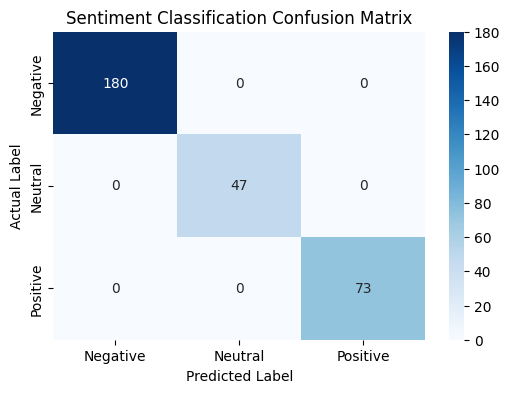

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Train the model if it wasn't run yet
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# 2. Generate predictions from the test set
y_pred = lr.predict(X_test)

# 3. Compute confusion matrix from test results
cm = confusion_matrix(y_test, y_pred)
labels = lr.classes_

# 4. Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
)
plt.title('Sentiment Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

***Saving the Trained Model and Vectorizer***

In [27]:
import joblib

# Save model and vectorizer to disk
joblib.dump(lr, 'mental_health_sentiment_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print('Trained model and TF-IDF vectorizer saved successfully!')

Trained model and TF-IDF vectorizer saved successfully!


***Real-Time Prediction Function for New Student Inputs***

In [28]:
import re
import string


def predict_student_sentiment(new_text):
  # Load saved model and vectorizer
  loaded_model = joblib.load('mental_health_sentiment_model.pkl')
  loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')

  # Clean the new text input using identical NLP steps
  text = str(new_text).lower()
  text = re.sub(r'http\S+|www\S+|https\S+', '', text)
  text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
  text = re.sub(r'\s+', ' ', text).strip()

  # Transform and predict
  vectorized_text = loaded_vectorizer.transform([text])
  prediction = loaded_model.predict(vectorized_text)

  return prediction[0]


# Test with a sample student check-in
sample_input = (
    'Feeling extremely stressed about upcoming exams and unable to sleep.'
)
predicted_result = predict_student_sentiment(sample_input)

print(f'Input Text     : {sample_input}')
print(f'Predicted State: {predicted_result}')

Input Text     : Feeling extremely stressed about upcoming exams and unable to sleep.
Predicted State: Negative


***Download Cleaned Dataset***

In [29]:
from google.colab import files

# Save the dataset to an Excel file
output_filename = "Mental_Health_Dataset_Cleaned_NLP.xlsx"
df.to_excel(output_filename, index=False)
print(f"Dataset successfully saved as: {output_filename}")

# Automatically trigger browser download in Google Colab
files.download(output_filename)

Dataset successfully saved as: Mental_Health_Dataset_Cleaned_NLP.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>